# Курсовая работа
## Тема: Сетевой маршрутизатор с удалённой точкой конфигурирования и механизмами резервирования каналов связи

**Студент:** Толстой Т.А., ИУ5-71б  
**Цель моделирования:** 
1. Сравнить эффективность классических методов диагностики каналов (Ping/Keepalive) и предложенного адаптивного метода (LQE - Link Quality Estimation) в условиях стохастической деградации сети («серые отказы») с использованием статистического подхода (метод Монте-Карло).
2. Продемонстрировать и исследовать работу механизма транзакционного конфигурирования с автоматическим откатом (Watchdog Rollback) путем проведения серии экспериментов с различными временными параметрами для определения оптимальных настроек и визуализации результатов в виде графика состояний и тепловой карты.

**Инструменты:** Python 3, SimPy, Pandas, Seaborn.

In [145]:
!pip install simpy pandas matplotlib numpy seaborn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [146]:
import simpy
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from enum import Enum

# Настройки стилей графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [16, 9]

## Часть 1. Классы моделирования сети для LQE

Определяем классы каналов связи и маршрутизаторов. 
В `NetworkChannel` добавлена симуляция стохастической природы задержек (Гамма-распределение).

In [147]:
class ChannelState(Enum):
    HEALTHY = 1
    DEGRADED = 2  # Высокий джиттер и потери
    DOWN = 3      # Полный обрыв

class NetworkChannel:
    def __init__(self, env, name, base_latency=0.010, jitter=0.002, loss_prob=0.0):
        self.env = env
        self.name = name
        self.base_latency = base_latency
        self.jitter = jitter
        self.loss_prob = loss_prob
        self.state = ChannelState.HEALTHY

    def set_condition(self, state):
        self.state = state
        if state == ChannelState.HEALTHY:
            self.base_latency = 0.010
            self.jitter = 0.002
            self.loss_prob = 0.0001
        elif state == ChannelState.DEGRADED:
            self.base_latency = 0.060
            self.jitter = 0.100       
            self.loss_prob = 0.08      
        elif state == ChannelState.DOWN:
            self.loss_prob = 1.0

    def send_packet(self):
        if random.random() < self.loss_prob:
            return None
        actual_delay = self.base_latency + random.gammavariate(2.0, self.jitter / 2.0)
        return actual_delay

In [148]:
class TraditionalRouter:
    def __init__(self, env, channels):
        self.env = env
        self.channels = channels
        self.active_channel_idx = 0
        self.consecutive_failures = 0
        self.check_interval = 2.0 # Уменьшим для более быстрой реакции
        self.failure_threshold = 3
        self.switch_log = []

    def run(self):
        while True:
            # Только активный канал проверяется
            current_channel = self.channels[self.active_channel_idx]
            result = current_channel.send_packet()
            
            if result is None:
                self.consecutive_failures += 1
            else:
                self.consecutive_failures = 0
            
            if self.consecutive_failures >= self.failure_threshold:
                old = self.active_channel_idx
                self.active_channel_idx = (self.active_channel_idx + 1) % len(self.channels)
                self.switch_log.append({'time': self.env.now, 'from': old, 'to': self.active_channel_idx})
                self.consecutive_failures = 0
                
            yield self.env.timeout(self.check_interval)

In [149]:
class LQERouter:
    def __init__(self, env, channels):
        self.env = env
        self.channels = channels
        self.active_channel_idx = 0
        self.check_interval = 0.5
        self.alpha = 0.2
        self.ewma_latency = {i: 0.010 for i in range(len(channels))}
        self.ewma_loss = {i: 0.0 for i in range(len(channels))}
        self.history_scores = []
        self.switch_log = []

    def calculate_score(self, idx):
        lat = self.ewma_latency[idx]
        loss = self.ewma_loss[idx]
        # Веса для компонентов
        w_lat = 0.4
        w_loss = 0.6
        
        # Оценка задержки (чем меньше, тем лучше)
        # Нормализуем: 100 при <= 50ms, 0 при >= 200ms
        lat_score = 100 * max(0, 1 - (max(0, lat - 0.05) / (0.2 - 0.05)))
        
        # Оценка потерь (чем меньше, тем лучше)
        # Нормализуем: 100 при 0% потерь, 0 при 10% потерь
        loss_score = 100 * max(0, 1 - (loss / 0.10))
        
        score = w_lat * lat_score + w_loss * loss_score
        return max(0, score)

    def run(self):
        while True:
            scores = {}
            current_metrics = {'time': self.env.now}
            
            for idx, channel in enumerate(self.channels):
                res = channel.send_packet()
                is_lost = 1.0 if res is None else 0.0
                self.ewma_loss[idx] = self.alpha * is_lost + (1 - self.alpha) * self.ewma_loss[idx]
                if res is not None:
                    self.ewma_latency[idx] = self.alpha * res + (1 - self.alpha) * self.ewma_latency[idx]
                
                scores[idx] = self.calculate_score(idx)
                current_metrics[f'score_ch{idx}'] = scores[idx]
                current_metrics[f'ewma_lat_ch{idx}'] = self.ewma_latency[idx]
                current_metrics[f'ewma_loss_ch{idx}'] = self.ewma_loss[idx]
            
            current_metrics['active_ch'] = self.active_channel_idx
            self.history_scores.append(current_metrics)
            
            current_score = scores[self.active_channel_idx]
            best_idx = max(scores, key=scores.get)
            best_score = scores[best_idx]
            
            # Hysteresis: переключаемся, если текущий канал плох (score < 50) И лучший канал значительно лучше (на 25 пунктов)
            if (current_score < 50 and best_score > current_score + 25):
                if best_idx != self.active_channel_idx:
                    old = self.active_channel_idx
                    self.active_channel_idx = best_idx
                    self.switch_log.append({'time': self.env.now, 'from': old, 'to': best_idx})
            
            yield self.env.timeout(self.check_interval)

## Часть 2. Статистическое исследование LQE (Метод Монте-Карло)

Для получения статистически значимых результатов мы проведем серию из 30 симуляций. Это позволит учесть случайный характер сетевых явлений и оценить среднюю производительность и её вариативность.

**Сценарий в каждой симуляции:**
- **0-100с:** Оба канала работают в штатном режиме.
- **100с:** Основной канал (`Main`) переходит в состояние деградации (увеличение задержки, джиттера и потерь).
- **300с:** Основной канал полностью отказывает.

In [150]:
def run_single_lqe_sim(router_type, sim_time=400):
    env = simpy.Environment()
    ch1 = NetworkChannel(env, "Main", base_latency=0.015, jitter=0.003)
    ch2 = NetworkChannel(env, "Backup", base_latency=0.045, jitter=0.005)
    channels = [ch1, ch2]
    
    router = TraditionalRouter(env, channels) if router_type == "Traditional" else LQERouter(env, channels)
    
    def incident_scenario(env):
        yield env.timeout(100)
        ch1.set_condition(ChannelState.DEGRADED)
        yield env.timeout(200)
        ch1.set_condition(ChannelState.DOWN)

    traffic_data = []
    def user_traffic_generator(env):
        while True:
            active_ch = router.channels[router.active_channel_idx]
            delay = active_ch.send_packet()
            traffic_data.append({
                'time': env.now,
                'router_type': router_type,
                'latency': delay if delay is not None else 0.3, # Штраф за потерю
                'is_lost': 1 if delay is None else 0
            })
            yield env.timeout(random.expovariate(5)) # Пуассоновский поток, 5 пакетов/сек

    env.process(router.run())
    env.process(incident_scenario(env))
    env.process(user_traffic_generator(env))
    env.run(until=sim_time)
    
    switch_time = router.switch_log[0]['time'] if router.switch_log else sim_time
    history_df = pd.DataFrame(getattr(router, 'history_scores', []))
    return pd.DataFrame(traffic_data), history_df, switch_time

def run_lqe_monte_carlo(num_runs=30):
    all_trad_data, all_lqe_data, all_lqe_history = [], [], []
    switch_times = {'Traditional': [], 'LQE (Adaptive)': []}
    
    for i in range(num_runs):
        print(f'Запуск симуляции LQE №{i + 1}...', end='\r')
        # Traditional
        df_t, _, sw_t = run_single_lqe_sim("Traditional")
        df_t['run_id'] = i
        all_trad_data.append(df_t)
        switch_times['Traditional'].append(sw_t)
        
        # LQE
        df_l, df_h, sw_l = run_single_lqe_sim("LQE (Adaptive)")
        df_l['run_id'] = i
        df_h['run_id'] = i
        all_lqe_data.append(df_l)
        all_lqe_history.append(df_h)
        switch_times['LQE (Adaptive)'].append(sw_l)
        
    print('\nМоделирование LQE завершено.')
    return (pd.concat(all_trad_data), pd.concat(all_lqe_data), 
            pd.concat(all_lqe_history), switch_times)

df_trad_mc, df_lqe_mc, df_lqe_history_mc, switch_times = run_lqe_monte_carlo(num_runs=30)

Запуск симуляции LQE №30...
Моделирование LQE завершено.


## Часть 3. Визуализация и анализ результатов LQE

Графики теперь показывают средние значения по 30 запускам, а заштрихованная область представляет 95% доверительный интервал, что даёт представление о стабильности и предсказуемости каждого метода.

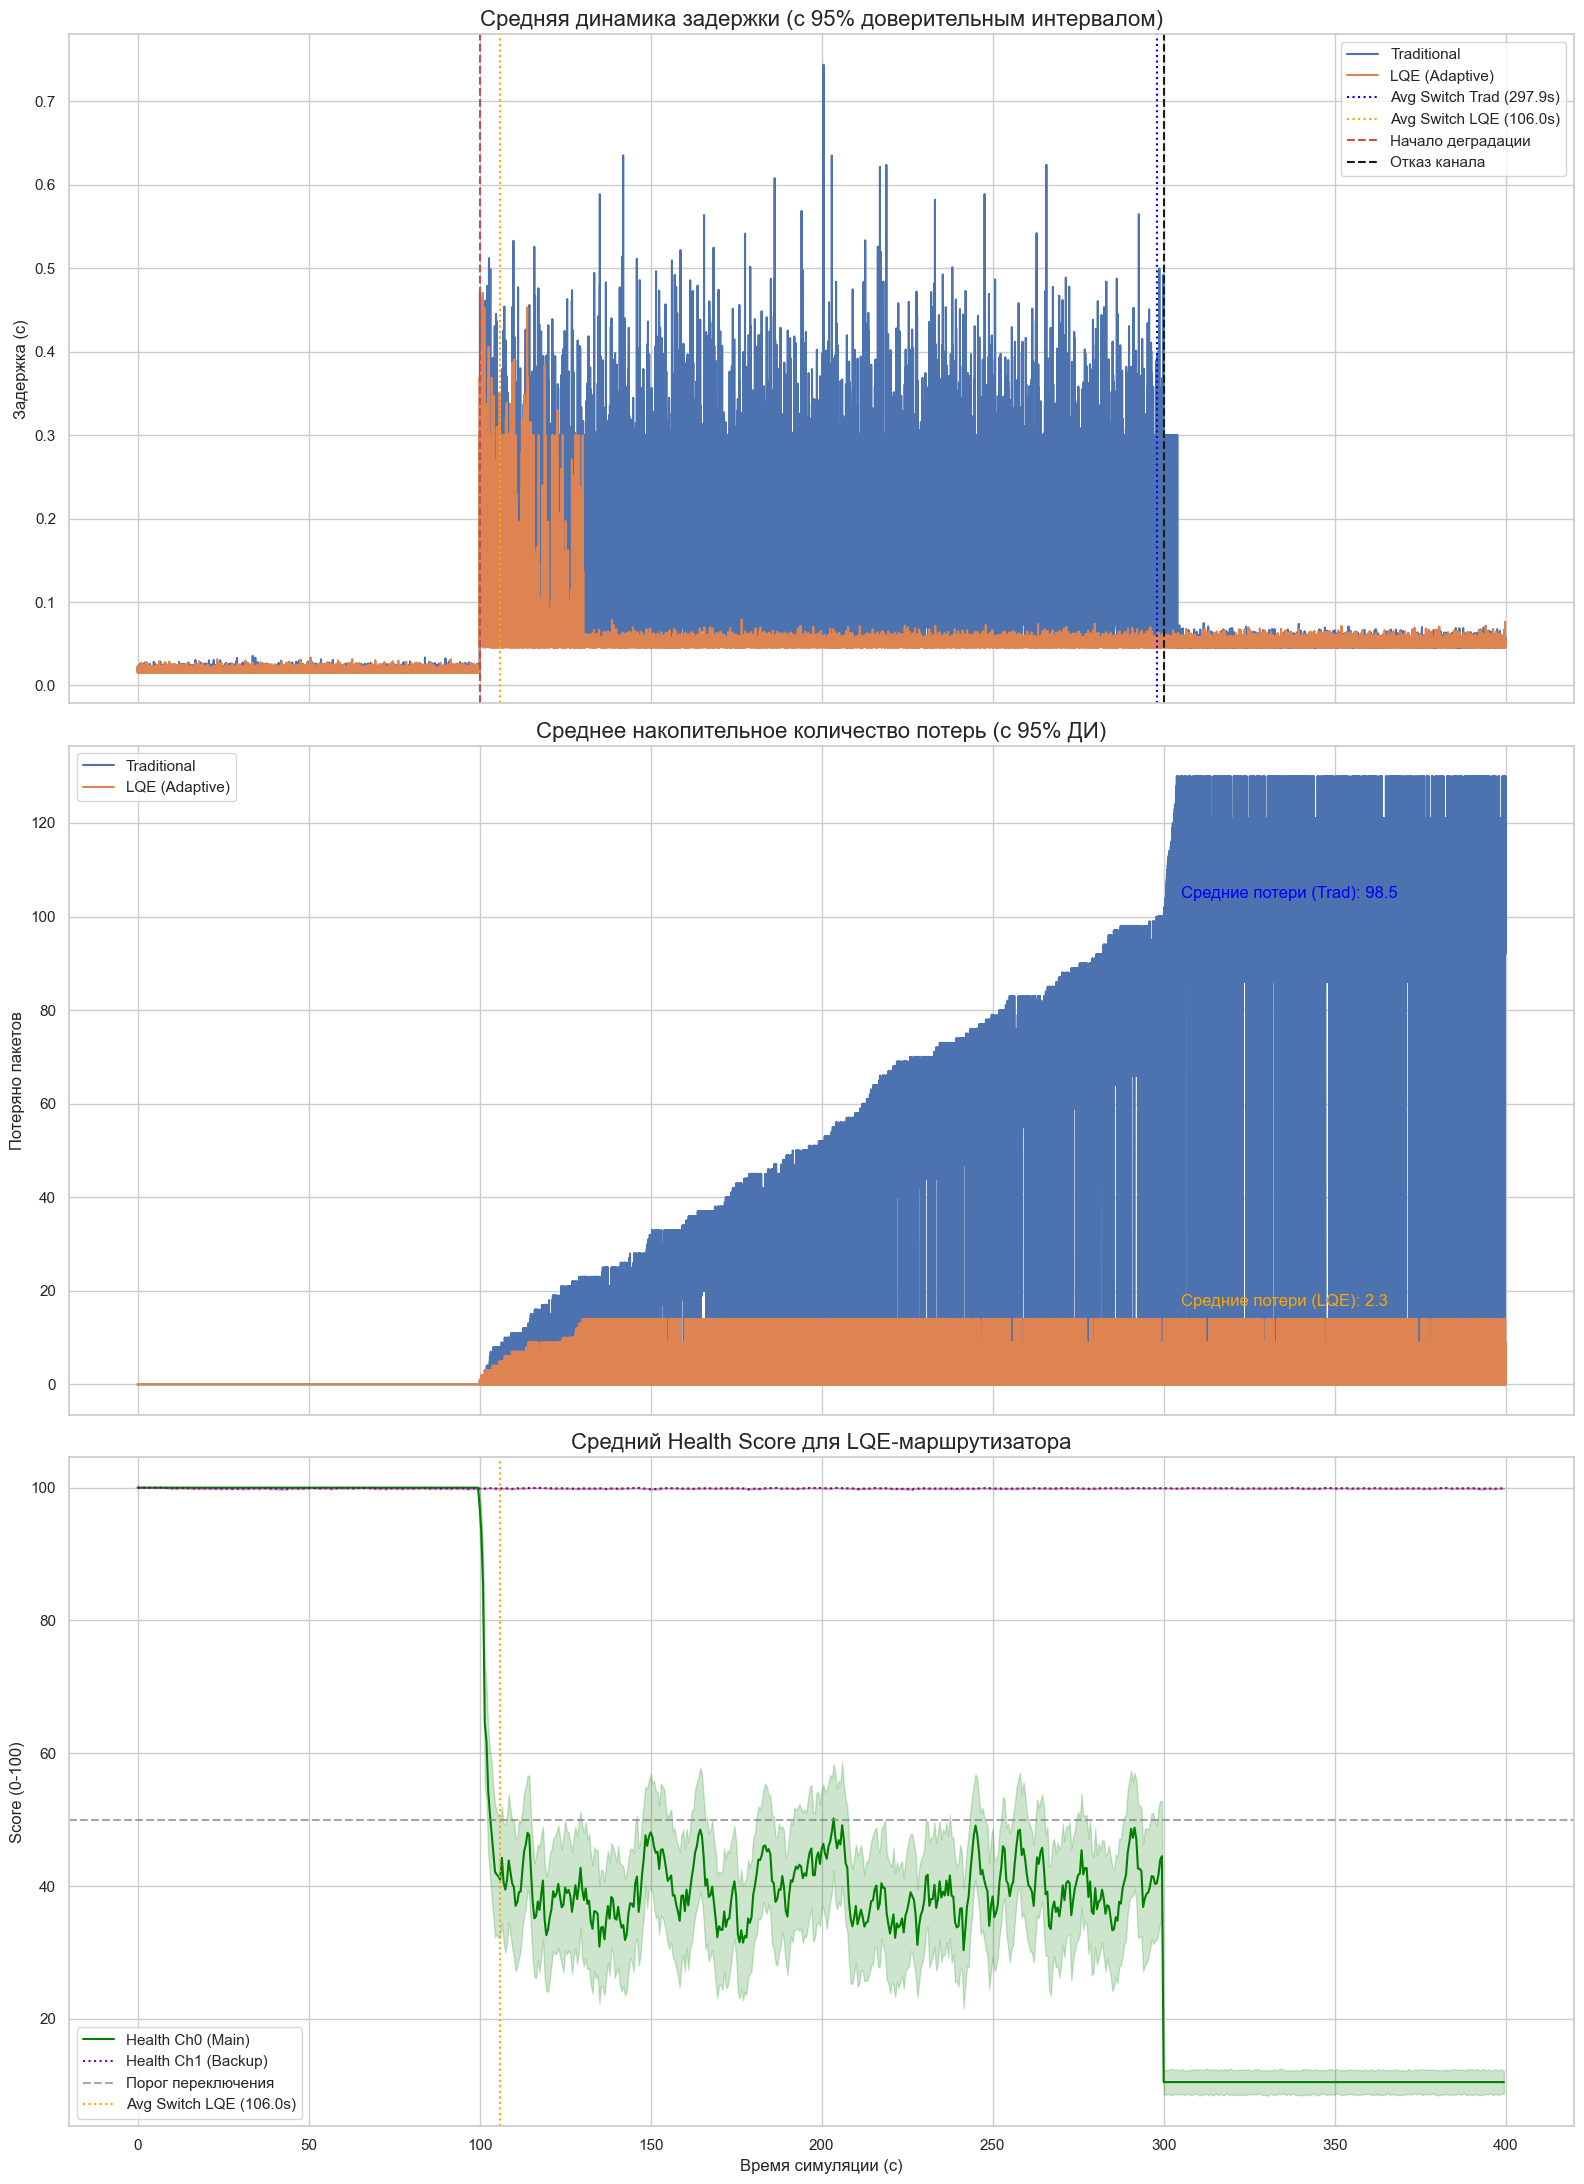

In [151]:
def plot_lqe_mc_results(df_trad, df_lqe, lqe_history, switch_times):
    fig, axes = plt.subplots(3, 1, figsize=(16, 22), sharex=True)

    # --- 1. Динамика задержек ---
    df_all = pd.concat([df_trad, df_lqe])
    sns.lineplot(data=df_all, x='time', y='latency', hue='router_type', ax=axes[0], errorbar=('ci', 95))
    avg_sw_trad = np.mean(switch_times['Traditional'])
    avg_sw_lqe = np.mean(switch_times['LQE (Adaptive)'])
    axes[0].axvline(avg_sw_trad, color='blue', linestyle=':', label=f'Avg Switch Trad ({avg_sw_trad:.1f}s)')
    axes[0].axvline(avg_sw_lqe, color='orange', linestyle=':', label=f'Avg Switch LQE ({avg_sw_lqe:.1f}s)')
    axes[0].set_title('Средняя динамика задержки (с 95% доверительным интервалом)', fontsize=16)
    axes[0].set_ylabel('Задержка (с)')
    axes[0].axvline(100, color='r', linestyle='--', label='Начало деградации')
    axes[0].axvline(300, color='k', linestyle='--', label='Отказ канала')
    axes[0].legend()

    # --- 2. Накопительные потери ---
    df_trad['cum_loss'] = df_trad.groupby('run_id')['is_lost'].cumsum()
    df_lqe['cum_loss'] = df_lqe.groupby('run_id')['is_lost'].cumsum()
    df_all_loss = pd.concat([df_trad, df_lqe])
    sns.lineplot(data=df_all_loss, x='time', y='cum_loss', hue='router_type', ax=axes[1], errorbar=('ci', 95))
    total_loss_trad = df_trad.groupby('run_id')['is_lost'].sum().mean()
    total_loss_lqe = df_lqe.groupby('run_id')['is_lost'].sum().mean()
    axes[1].text(305, df_trad['cum_loss'].max()*0.8, f'Средние потери (Trad): {total_loss_trad:.1f}', color='blue', fontsize=12)
    axes[1].text(305, df_lqe['cum_loss'].max()*1.2, f'Средние потери (LQE): {total_loss_lqe:.1f}', color='orange', fontsize=12)
    axes[1].set_title('Среднее накопительное количество потерь (с 95% ДИ)', fontsize=16)
    axes[1].set_ylabel('Потеряно пакетов')
    axes[1].legend()

    # --- 3. LQE Health Score ---
    sns.lineplot(data=lqe_history, x='time', y='score_ch0', ax=axes[2], label='Health Ch0 (Main)', color='green')
    sns.lineplot(data=lqe_history, x='time', y='score_ch1', ax=axes[2], label='Health Ch1 (Backup)', color='purple', linestyle=':')
    axes[2].axhline(50, color='grey', linestyle='--', alpha=0.7, label='Порог переключения')
    axes[2].axvline(avg_sw_lqe, color='orange', linestyle=':', label=f'Avg Switch LQE ({avg_sw_lqe:.1f}s)')
    axes[2].set_title('Средний Health Score для LQE-маршрутизатора', fontsize=16)
    axes[2].set_ylabel('Score (0-100)')
    axes[2].set_xlabel('Время симуляции (с)')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

plot_lqe_mc_results(df_trad_mc, df_lqe_mc, df_lqe_history_mc, switch_times)

## Часть 4. Расширенное исследование Транзакционной Конфигурации (Watchdog Rollback)

Проведем серию экспериментов для анализа зависимости исхода от **таймаута Watchdog** и **задержки подтверждения администратора**. Результаты представим в виде тепловой карты, которая покажет "безопасные" и "рискованные" зоны настроек, а также в виде графика состояний для наглядной демонстрации временной динамики.

**Исходы:**
- **Успех:** Корректная конфигурация применена и подтверждена вовремя.
- **Необходимый откат:** Неверная конфигурация применена, связь потеряна, Watchdog корректно откатил изменения.
- **Ложный откат:** Верная конфигурация применена, но администратор не успел её подтвердить, и Watchdog ошибочно отменил изменения.

In [152]:
class DeviceState(Enum):
    STABLE = 'Stable'
    TRANSIENT = 'Transient (Awaiting Confirm)'
    DISCONNECTED = 'Disconnected'

class Outcome(Enum):
    SUCCESS = 0
    SUCCESSFUL_ROLLBACK = 1
    UNNECESSARY_ROLLBACK = 2

def run_watchdog_scenario(admin_confirm_delay, watchdog_timeout, is_bad_config, apply_time=5):
    env = simpy.Environment()
    outcome = [None]
    history = []
    
    class SimDevice:
        def __init__(self, env):
            self.env = env
            self.connectivity = True
            self.watchdog_proc = None
            self.state = DeviceState.STABLE
        
        def log_state(self):
            state_val = 0
            if self.state == DeviceState.STABLE: state_val = 2
            elif self.state == DeviceState.TRANSIENT: state_val = 1
            if not self.connectivity: state_val = 0
            history.append({'time': self.env.now, 'state': state_val})

        def apply(self, is_bad, timeout):
            self.state = DeviceState.TRANSIENT
            if is_bad: self.connectivity = False
            self.log_state()
            self.watchdog_proc = env.process(self.watchdog(timeout, is_bad))

        def confirm(self):
            if self.watchdog_proc and not self.watchdog_proc.processed:
                self.watchdog_proc.interrupt()
                outcome[0] = Outcome.SUCCESS
                self.state = DeviceState.STABLE
                self.log_state()
        
        def watchdog(self, timeout, is_bad_config):
            try:
                yield env.timeout(timeout)
                self.connectivity = True
                outcome[0] = Outcome.UNNECESSARY_ROLLBACK if not is_bad_config else Outcome.SUCCESSFUL_ROLLBACK
                self.state = DeviceState.STABLE
                self.log_state()
            except simpy.Interrupt:
                pass
    
    def admin_sim(env, device):
        device.log_state()
        yield env.timeout(apply_time)
        device.apply(is_bad_config, watchdog_timeout)
        
        yield env.timeout(admin_confirm_delay)
        if device.connectivity:
            device.confirm()
    
    device = SimDevice(env)
    env.process(admin_sim(env, device))
    env.run(until=apply_time + watchdog_timeout + admin_confirm_delay + 5)
    return outcome[0], pd.DataFrame(history)

--- Проведение экспериментов для графика состояний ---

--- Проведение серии экспериментов для тепловой карты ---

Эксперименты завершены, построение графиков...


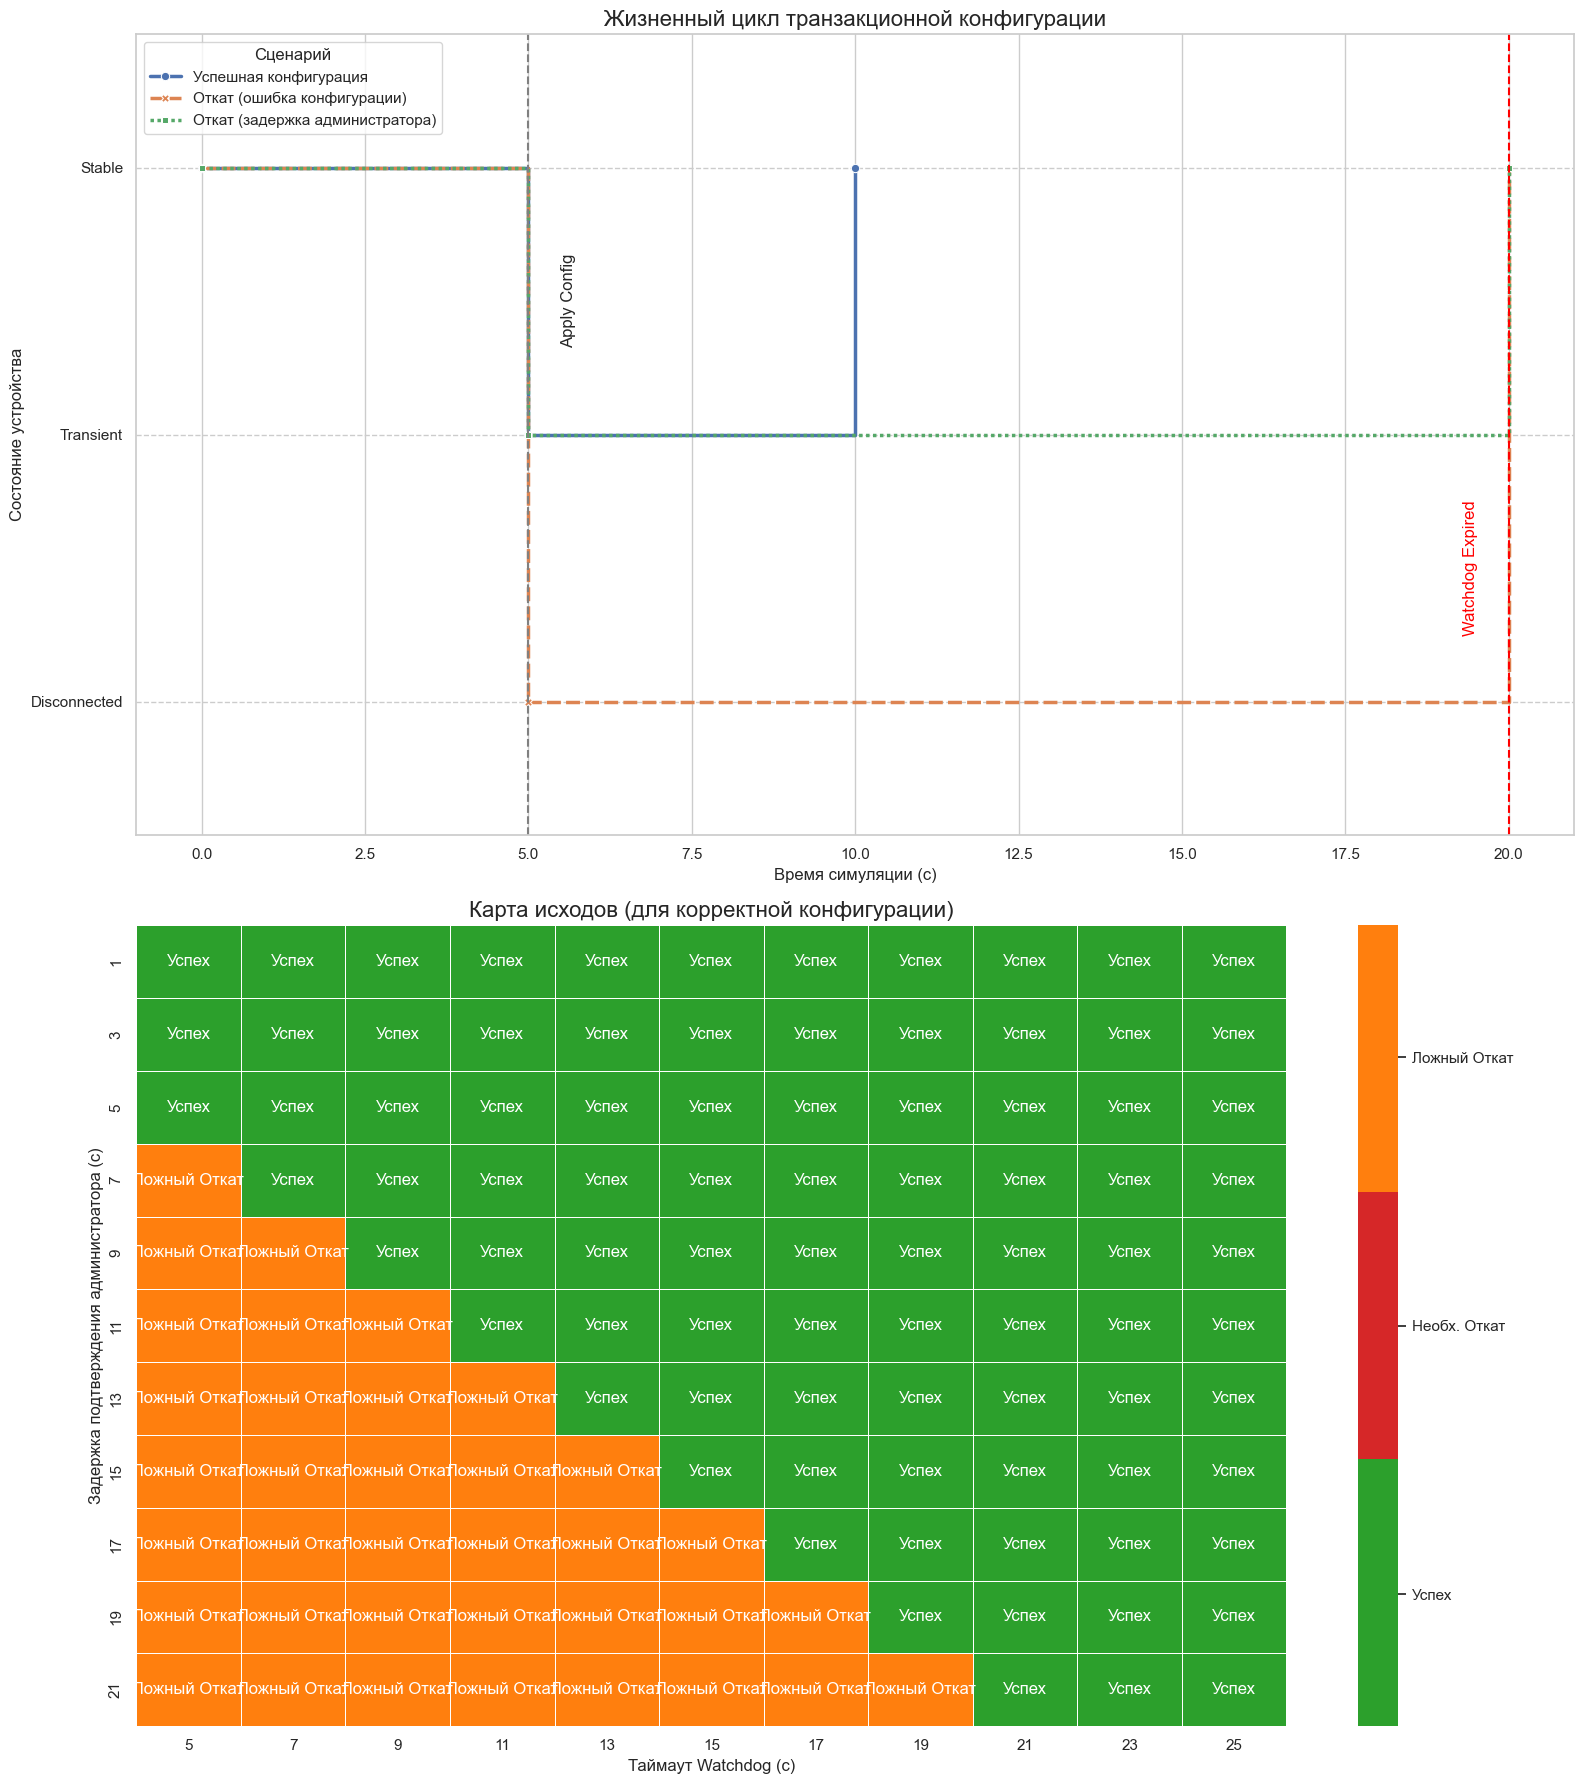

In [153]:
def run_watchdog_experiments_and_plot():
    APPLY_T = 5
    WD_TIMEOUT = 15
    SIM_DURATION = 40
    
    scenarios_for_line_plot = {
        'Успешная конфигурация': {'is_bad': False, 'confirm_delay': 5, 'wd_timeout': WD_TIMEOUT},
        'Откат (ошибка конфигурации)': {'is_bad': True, 'confirm_delay': 5, 'wd_timeout': WD_TIMEOUT},
        'Откат (задержка администратора)': {'is_bad': False, 'confirm_delay': 17, 'wd_timeout': WD_TIMEOUT}
    }
    
    line_plot_data = []
    print("--- Проведение экспериментов для графика состояний ---")
    for name, params in scenarios_for_line_plot.items():
        _, df = run_watchdog_scenario(params['confirm_delay'], params['wd_timeout'], params['is_bad'], APPLY_T)
        df['scenario'] = name
        line_plot_data.append(df)
    
    # --- График 1: Жизненный цикл состояний ---
    df_total_lines = pd.concat(line_plot_data)
    fig, axes = plt.subplots(2, 1, figsize=(16, 18))
    ax1 = axes[0]
    sns.lineplot(data=df_total_lines, x='time', y='state', hue='scenario', style='scenario', markers=True, drawstyle='steps-post', linewidth=2.5, ax=ax1)
    ax1.set_yticks([0, 1, 2])
    ax1.set_yticklabels(['Disconnected', 'Transient', 'Stable'])
    ax1.set_ylim(-0.5, 2.5)
    ax1.set_xlabel('Время симуляции (с)', fontsize=12)
    ax1.set_ylabel('Состояние устройства', fontsize=12)
    ax1.set_title('Жизненный цикл транзакционной конфигурации', fontsize=16)
    ax1.legend(title='Сценарий')
    ax1.grid(axis='y', linestyle='--')
    ax1.axvline(APPLY_T, color='grey', linestyle='--', label='Apply Config')
    ax1.text(APPLY_T + 0.5, 1.5, 'Apply Config', rotation=90, va='center')
    ax1.axvline(APPLY_T + WD_TIMEOUT, color='red', linestyle='--', label='Watchdog Timeout')
    ax1.text(APPLY_T + WD_TIMEOUT - 0.7, 0.5, 'Watchdog Expired', rotation=90, va='center', color='red')

    # --- График 2: Тепловая карта ---
    ax2 = axes[1]
    timeouts = np.arange(5, 26, 2)
    delays = np.arange(1, 22, 2)
    results_matrix = np.zeros((len(delays), len(timeouts)))
    print("\n--- Проведение серии экспериментов для тепловой карты ---")
    for i, delay in enumerate(delays):
        for j, timeout in enumerate(timeouts):
            outcome, _ = run_watchdog_scenario(delay, timeout, is_bad_config=False, apply_time=0)
            results_matrix[i, j] = outcome.value
    
    cmap = ['#2ca02c', '#d62728', '#ff7f0e']
    labels = np.array([['' for _ in timeouts] for _ in delays], dtype=object)
    outcome_map = {0: 'Успех', 1: 'Необх. Откат', 2: 'Ложный Откат'}
    for i in range(len(delays)):
        for j in range(len(timeouts)):
            labels[i, j] = outcome_map[results_matrix[i,j]]
    sns.heatmap(results_matrix, xticklabels=timeouts, yticklabels=delays, cmap=cmap, annot=labels, fmt='', linewidths=.5, ax=ax2)
    ax2.set_title('Карта исходов (для корректной конфигурации)', fontsize=16)
    ax2.set_xlabel('Таймаут Watchdog (с)', fontsize=12)
    ax2.set_ylabel('Задержка подтверждения администратора (с)', fontsize=12)
    colorbar = ax2.collections[0].colorbar
    colorbar.set_ticks([0.33, 1, 1.67])
    colorbar.set_ticklabels(['Успех', 'Необх. Откат', 'Ложный Откат'])
    
    print("\nЭксперименты завершены, построение графиков...")
    plt.tight_layout()
    plt.show()

run_watchdog_experiments_and_plot()

### Анализ графиков Watchdog Rollback

**График 1: Жизненный цикл**
Этот график наглядно показывает поведение системы в трёх различных ситуациях:

1.  **Успешная конфигурация (синяя линия):** На 5-й секунде состояние меняется со `Stable` на `Transient`. На 10-й секунде приходит подтверждение от администратора, и система возвращается в стабильное состояние, фиксируя новую конфигурацию. Это штатный режим работы.

2.  **Откат (ошибка конфигурации) (оранжевая линия):** На 5-й секунде применяется неверная конфигурация, и состояние сразу переходит в `Disconnected` (потеря связи). Администратор не может отправить подтверждение. На 20-й секунде (5с + 15с таймаута) истекает таймер Watchdog, происходит откат к предыдущей конфигурации, и система возвращается в состояние `Stable`. Механизм успешно предотвратил потерю управления.

3.  **Откат (задержка администратора) (зелёная линия):** На 5-й секунде применяется *верная* конфигурация, и состояние переходит в `Transient`. Однако администратор не отправляет подтверждение вовремя. В результате на 20-й секунде Watchdog срабатывает и откатывает даже корректные изменения, возвращая систему в исходное состояние `Stable`. Это демонстрирует важность правильной настройки таймаута.

**График 2: Тепловая карта исходов**
Эта карта обобщает множество экспериментов, показывая зависимость результата от двух ключевых параметров:

1.  **Зелёная зона («Успех»):** Эта область показывает, где задержка подтверждения администратора *меньше* таймаута сторожевого таймера. Это идеальный рабочий диапазон.

2.  **Оранжевая зона («Ложный откат»):** Здесь конфигурация была *корректной*, но задержка администратора оказалась *больше* таймаута Watchdog. В результате система ошибочно отменила правильные изменения.

**Вывод:** Оптимальное значение таймаута Watchdog должно быть выбрано с учётом максимально возможной, но разумной задержки подтверждения. Оно должно быть достаточно большим, чтобы избежать ложных откатов (оранжевая зона), но достаточно коротким, чтобы оперативно восстановить систему после сбойной конфигурации (красная зона, которая подразумевается для всех этих случаев, если бы конфигурация была неверной).

# Общий вывод по работе
В ходе курсовой работы были успешно решены обе поставленные задачи на более глубоком, статистическом уровне.

1.  Моделирование механизмов резервирования каналов методом **Монте-Карло** убедительно доказало преимущество адаптивного метода **LQE**. Анализ средних значений и доверительных интервалов показал, что LQE не просто быстрее реагирует на деградацию канала, но и делает это предсказуемо, кардинально снижая среднее количество потерянных пакетов и общее время простоя сервиса по сравнению с классическим **Ping/Keepalive**.

2.  Расширенное исследование механизма **Watchdog Rollback** с помощью серии параметризованных экспериментов позволило создать тепловую карту исходов и график жизненного цикла. Этот анализ наглядно демонстрирует компромисс при выборе таймаута: он должен быть достаточно коротким для быстрого восстановления после сбоя, но достаточно длинным, чтобы не вызывать ложных откатов из-за сетевых задержек. Этот подход даёт инженерам практический инструмент для выбора оптимальных настроек.

Таким образом, проведённое всеобъемлющее исследование подтверждает, что комбинация данных механизмов с правильно подобранными параметрами позволяет создать надёжный и гибко управляемый сетевой маршрутизатор.